# Comparación de modelos — Detección de datos de contacto

Este notebook **no entrena nada**. Levanta los `test_predictions.csv` que produjeron los demás notebooks y arma la comparación final que va al paper.

## Runbook — orden sugerido para correr todo

1. **YOLOv8n** (modelo principal): correr `tp_final.ipynb` end-to-end con `MODEL_SIZE = 'n'` (default). Guarda en `work/yolov8n/test_predictions.csv`.
2. **YOLOv8s** (variante grande): abrir `tp_final.ipynb` ➜ celda 2 (Config) ➜ cambiar `MODEL_SIZE = 's'` ➜ *Restart & Run All*. Los caches de OCR y dataset_yolo se reusan; solo se re-entrena el modelo. Guarda en `work/yolov8s/test_predictions.csv`.
3. **EfficientNet-B0** (baseline clasificador): correr `TP_VC2_RU.ipynb` end-to-end. Guarda en `work/efficientnet_b0/test_predictions.csv`.
4. **ResNet50 + CAM** (clasificador con localización via Class Activation Map): correr `TP_VC2_LD.ipynb` end-to-end. Guarda en `work/resnet50_cam/test_predictions.csv`. Para el pipeline E2E con OCR (no necesario para la comparación), instalar `brew install tesseract tesseract-lang`.
5. **OCR + regex** (baseline sin detector): correr `baseline_ocr_regex.ipynb`. Guarda en `work/baseline_ocr_regex/test_predictions.csv`. La parte lenta (OCR sobre 3000 imágenes) cachea a `work/ocr_cache/test_ocr.json`.
6. **Este notebook (`comparison.ipynb`)**: ejecutar al final. Levanta los CSVs que encuentre y arma la tabla.

Si un modelo todavía no corrió, lo saltea — podés ir refrescando este notebook a medida que sumás resultados.

## Schema esperado por modelo
```
image_path, label, score, pred, model_name
```

## Producto final
- Tabla comparativa de Precision / Recall / F1 / AUC-PR / AUC-ROC.
- Bar chart de métricas por modelo.
- PR curves + ROC curves superpuestas.
- Matrices de confusión lado a lado.
- Tabla en formato Markdown lista para pegar en el paper.
- Análisis cruzado: ¿en qué imágenes coinciden / discrepan los modelos?


## 1. Setup

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    precision_recall_curve, average_precision_score,
    roc_curve, roc_auc_score,
    confusion_matrix,
)

PROJECT_ROOT = Path.cwd()
WORK_DIR     = PROJECT_ROOT / 'work'
OUT_DIR      = WORK_DIR / 'comparison'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('WORK_DIR:', WORK_DIR)


WORK_DIR: C:\git\tp_vp2\work


## 2. Descubrir modelos disponibles

Buscamos cualquier `work/*/test_predictions.csv`. Si un modelo todavía no corrió, lo salteamos en lugar de fallar.

In [2]:
REQUIRED_COLS = {'image_path', 'label', 'score', 'pred', 'model_name'}

def load_all_predictions(work_dir):
    preds_by_model = {}
    for csv in sorted(work_dir.glob('*/test_predictions.csv')):
        df = pd.read_csv(csv)
        missing = REQUIRED_COLS - set(df.columns)
        if missing:
            print(f'[WARN] {csv} no tiene columnas: {missing}. Saltado.')
            continue
        model = df['model_name'].iloc[0]
        preds_by_model[model] = df
        print(f'  {model:25s} {len(df):5d} filas  ←  {csv.relative_to(work_dir.parent)}')
    return preds_by_model

predictions = load_all_predictions(WORK_DIR)
print(f'\nModelos encontrados: {len(predictions)}')
assert len(predictions) >= 1, 'No se encontró ningún test_predictions.csv en work/*/'


  baseline_ocr_regex         3000 filas  ←  work\baseline_ocr_regex\test_predictions.csv
  efficientnet_b0            3000 filas  ←  work\efficientnet_b0\test_predictions.csv
  resnet50_cam               3000 filas  ←  work\resnet50_cam\test_predictions.csv
  yolov8n                    3000 filas  ←  work\yolov8n\test_predictions.csv
  yolov8s                    3000 filas  ←  work\yolov8s\test_predictions.csv

Modelos encontrados: 5


## 3. Sanity check: mismo test set en todos los modelos

Si los modelos se evaluaron sobre subsets distintos, las métricas no son comparables. Acá verificamos.

In [3]:
sizes = {m: len(df) for m, df in predictions.items()}
image_sets = {m: set(df['image_path']) for m, df in predictions.items()}

print('Tamaños:')
for m, n in sizes.items(): print(f'  {m:25s} {n} imágenes')

all_paths = set.intersection(*image_sets.values()) if image_sets else set()
print(f'\nIntersección (imágenes en todos los modelos): {len(all_paths)}')

if len(set(sizes.values())) > 1:
    print('\n[WARN] Los modelos no tienen el mismo tamaño de test set.')
    print('       Limitamos la comparación a la intersección.')
    for m, df in predictions.items():
        predictions[m] = df[df['image_path'].isin(all_paths)].copy()
        print(f'  {m}: {len(predictions[m])} (filtrado)')
else:
    print('OK: todos los modelos evaluaron sobre el mismo set.')


Tamaños:
  baseline_ocr_regex        3000 imágenes
  efficientnet_b0           3000 imágenes
  resnet50_cam              3000 imágenes
  yolov8n                   3000 imágenes
  yolov8s                   3000 imágenes

Intersección (imágenes en todos los modelos): 3000
OK: todos los modelos evaluaron sobre el mismo set.


## 4. Métricas por modelo

In [4]:
def compute_metrics(df):
    y_true = df['label'].values
    y_pred = df['pred'].values
    scores = df['score'].values
    metrics = {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
    }
    # AUC-PR y AUC-ROC requieren scores continuos y al menos un positivo y un negativo
    try:    metrics['auc_pr']  = average_precision_score(y_true, scores)
    except: metrics['auc_pr']  = np.nan
    try:    metrics['auc_roc'] = roc_auc_score(y_true, scores)
    except: metrics['auc_roc'] = np.nan
    return metrics

rows = []
for model, df in predictions.items():
    m = compute_metrics(df)
    m['model'] = model
    m['n_test'] = len(df)
    m['n_pos'] = int(df['label'].sum())
    rows.append(m)

metrics_df = (
    pd.DataFrame(rows)
      [['model', 'n_test', 'n_pos', 'accuracy', 'precision', 'recall', 'f1', 'auc_pr', 'auc_roc']]
      .sort_values('f1', ascending=False)
      .reset_index(drop=True)
)
metrics_df.to_csv(OUT_DIR / 'metrics_summary.csv', index=False)
metrics_df.style.format({'accuracy': '{:.4f}', 'precision': '{:.4f}',
                         'recall': '{:.4f}', 'f1': '{:.4f}',
                         'auc_pr': '{:.4f}', 'auc_roc': '{:.4f}'})


,model,n_test,n_pos,accuracy,precision,recall,f1,auc_pr,auc_roc
0,baseline_ocr_regex,3000,93,0.9663,0.4091,0.1935,0.2628,0.1455,0.5925
1,efficientnet_b0,3000,93,0.8537,0.1440,0.7527,0.2418,0.2077,0.8801
2,resnet50_cam,3000,93,0.8383,0.1316,0.7527,0.2240,0.2019,0.8789
3,yolov8n,3000,93,0.9153,0.1390,0.3333,0.1962,0.1419,0.7184
4,yolov8s,3000,93,0.9107,0.1308,0.3333,0.1879,0.1433,0.7293


## 5. Comparación visual

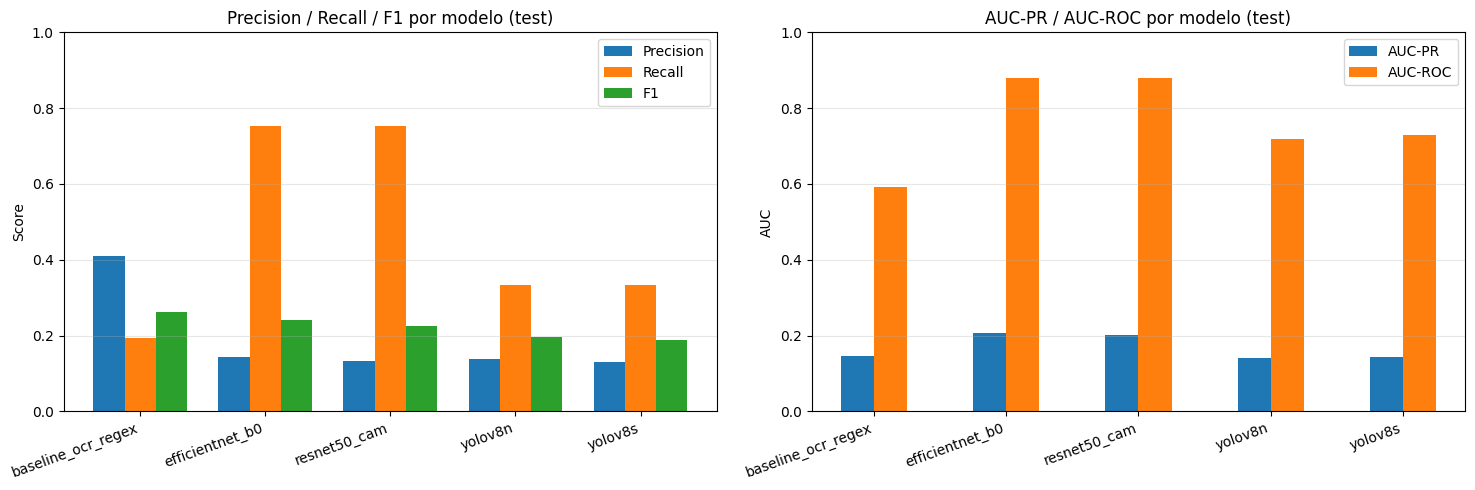

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# F1 por modelo
ax = axes[0]
models = metrics_df['model'].tolist()
x = np.arange(len(models))
width = 0.25
ax.bar(x - width, metrics_df['precision'], width, label='Precision')
ax.bar(x,         metrics_df['recall'],    width, label='Recall')
ax.bar(x + width, metrics_df['f1'],        width, label='F1')
ax.set_xticks(x); ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('Score'); ax.set_title('Precision / Recall / F1 por modelo (test)')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# AUC-PR / AUC-ROC
ax = axes[1]
ax.bar(x - width/2, metrics_df['auc_pr'],  width, label='AUC-PR')
ax.bar(x + width/2, metrics_df['auc_roc'], width, label='AUC-ROC')
ax.set_xticks(x); ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('AUC'); ax.set_title('AUC-PR / AUC-ROC por modelo (test)')
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'metrics_barplot.png', dpi=150, bbox_inches='tight')
plt.show()


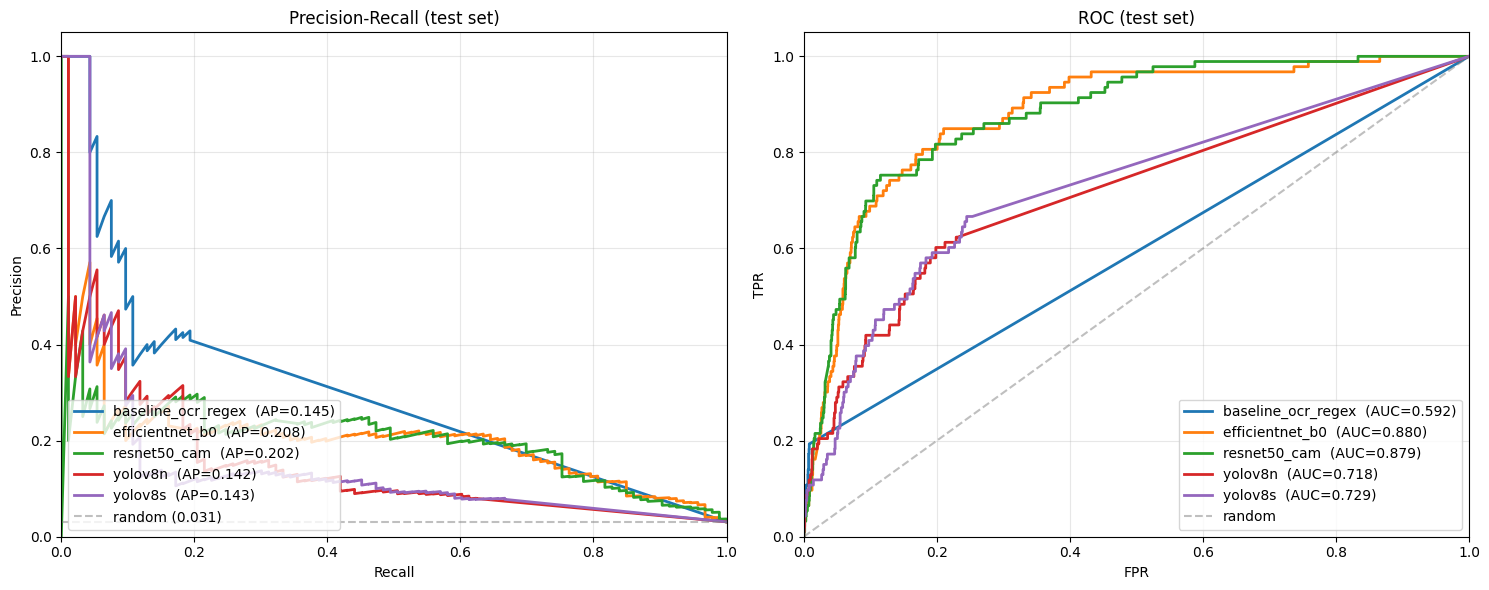

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Precision-Recall curves
ax = axes[0]
for model, df in predictions.items():
    p, r, _ = precision_recall_curve(df['label'], df['score'])
    ap = average_precision_score(df['label'], df['score'])
    ax.plot(r, p, label=f'{model}  (AP={ap:.3f})', linewidth=2)
# Baseline aleatorio: positivo_rate
pos_rate = next(iter(predictions.values()))['label'].mean()
ax.axhline(pos_rate, color='gray', linestyle='--', alpha=0.5, label=f'random ({pos_rate:.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall (test set)')
ax.legend(loc='lower left'); ax.grid(alpha=0.3); ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)

# ROC curves
ax = axes[1]
for model, df in predictions.items():
    fpr, tpr, _ = roc_curve(df['label'], df['score'])
    auc = roc_auc_score(df['label'], df['score'])
    ax.plot(fpr, tpr, label=f'{model}  (AUC={auc:.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.5, label='random')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC (test set)')
ax.legend(loc='lower right'); ax.grid(alpha=0.3); ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(OUT_DIR / 'pr_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


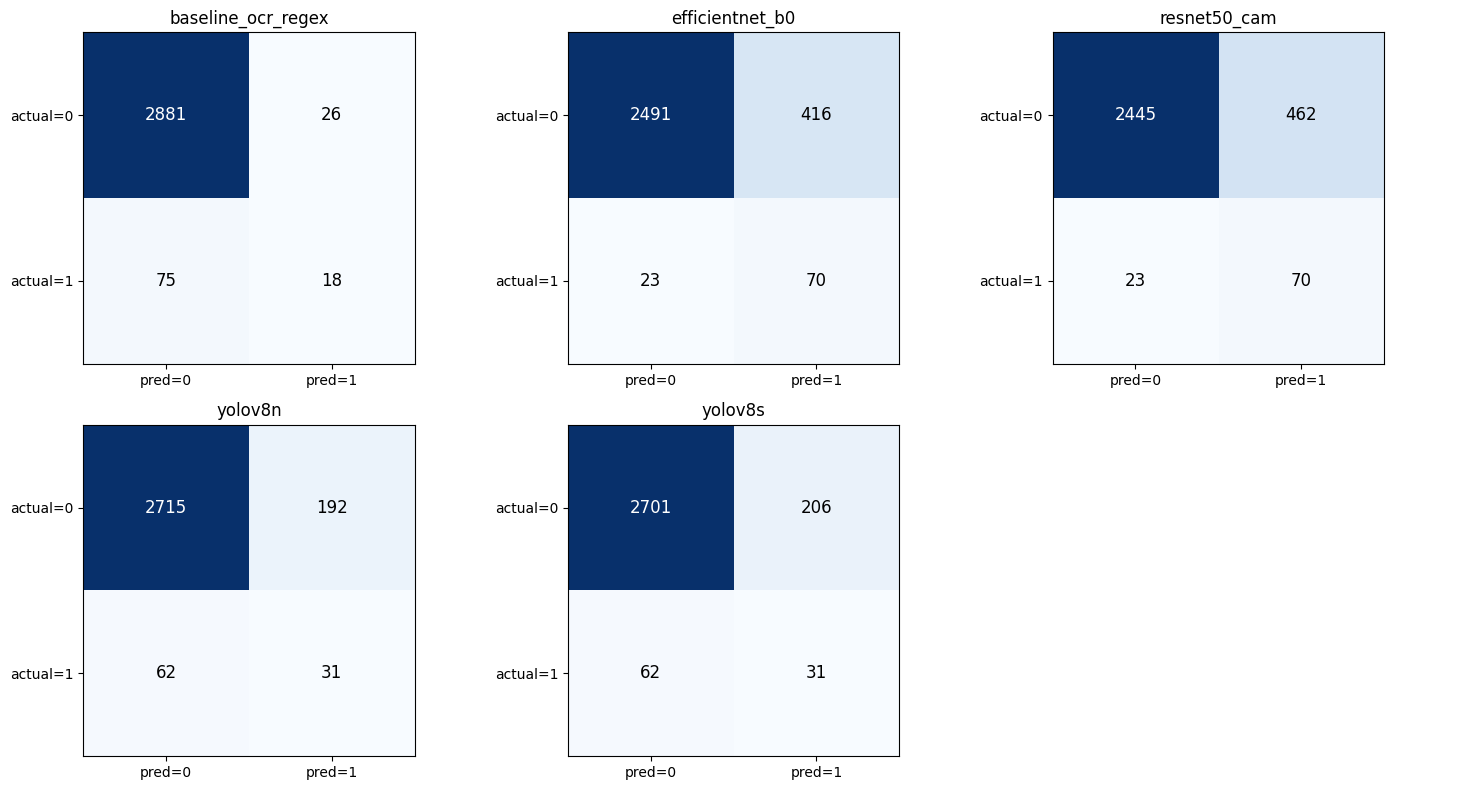

In [7]:
n = len(predictions)
ncols = min(n, 3); nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.atleast_2d(axes).flatten()

for ax, (model, df) in zip(axes, predictions.items()):
    cm = confusion_matrix(df['label'], df['pred'])
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(model)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['pred=0', 'pred=1'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['actual=0', 'actual=1'])
    # Anotaciones con cantidad
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha='center', va='center',
                color='white' if v > cm.max() / 2 else 'black', fontsize=12)
for ax in axes[n:]:
    ax.axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Análisis cruzado de predicciones

¿Cuándo coinciden todos los modelos? ¿Cuándo discrepan? Esto da material para discutir en el paper qué tipos de errores son específicos de cada enfoque.

In [8]:
# Tabla wide: una fila por imagen, una columna pred_{model} por modelo
if len(predictions) >= 2:
    wide = None
    for model, df in predictions.items():
        cols = df[['image_path', 'label', 'pred', 'score']].rename(
            columns={'pred': f'pred_{model}', 'score': f'score_{model}'}
        )
        wide = cols if wide is None else wide.merge(cols, on=['image_path', 'label'])

    pred_cols = [c for c in wide.columns if c.startswith('pred_')]
    wide['n_agree_positive'] = wide[pred_cols].sum(axis=1)
    wide['all_agree'] = (wide['n_agree_positive'] == 0) | (wide['n_agree_positive'] == len(pred_cols))

    print(f'Total imágenes: {len(wide)}')
    print(f'Modelos en acuerdo (todos 0 o todos 1): {wide["all_agree"].sum()} '
          f'({wide["all_agree"].mean()*100:.1f}%)')
    print(f'Modelos en desacuerdo: {(~wide["all_agree"]).sum()} '
          f'({(~wide["all_agree"]).mean()*100:.1f}%)')

    print('\nDesglose por nivel de acuerdo positivo (cuántos modelos votaron 1):')
    print(wide.groupby(['label', 'n_agree_positive']).size().unstack(fill_value=0))

    wide.to_csv(OUT_DIR / 'predictions_wide.csv', index=False)
else:
    print('Solo hay 1 modelo cargado — no hay análisis cruzado posible.')


Total imágenes: 3000
Modelos en acuerdo (todos 0 o todos 1): 2134 (71.1%)
Modelos en desacuerdo: 866 (28.9%)

Desglose por nivel de acuerdo positivo (cuántos modelos votaron 1):
n_agree_positive     0    1    2   3   4  5
label                                      
0                 2118  393  298  79  19  0
1                   11   12   32  13  20  5


## 7. Tabla en Markdown para el paper

Se guarda en `work/comparison/metrics_table.md`. Pegar directo en el paper (IEEE Word) — la mayoría de los editores acepta tablas markdown o las convertís rápido con un convertidor online.

In [9]:
def df_to_markdown(df, float_fmt='{:.4f}'):
    cols = df.columns.tolist()
    lines = ['| ' + ' | '.join(cols) + ' |',
             '|' + '|'.join(['---'] * len(cols)) + '|']
    for _, row in df.iterrows():
        vals = []
        for c in cols:
            v = row[c]
            if isinstance(v, float): vals.append(float_fmt.format(v))
            else: vals.append(str(v))
        lines.append('| ' + ' | '.join(vals) + ' |')
    return '\n'.join(lines)

md_table = df_to_markdown(metrics_df)
(OUT_DIR / 'metrics_table.md').write_text(md_table)
print(md_table)


| model | n_test | n_pos | accuracy | precision | recall | f1 | auc_pr | auc_roc |
|---|---|---|---|---|---|---|---|---|
| baseline_ocr_regex | 3000 | 93 | 0.9663 | 0.4091 | 0.1935 | 0.2628 | 0.1455 | 0.5925 |
| efficientnet_b0 | 3000 | 93 | 0.8537 | 0.1440 | 0.7527 | 0.2418 | 0.2077 | 0.8801 |
| resnet50_cam | 3000 | 93 | 0.8383 | 0.1316 | 0.7527 | 0.2240 | 0.2019 | 0.8789 |
| yolov8n | 3000 | 93 | 0.9153 | 0.1390 | 0.3333 | 0.1962 | 0.1419 | 0.7184 |
| yolov8s | 3000 | 93 | 0.9107 | 0.1308 | 0.3333 | 0.1879 | 0.1433 | 0.7293 |


## 8. Latencia de inferencia (si está disponible)

Para el paper conviene reportar también ms/imagen. La baseline OCR+regex ya guarda `latency_stats.json`; los otros notebooks lo pueden completar después.

In [10]:
latency_rows = []
for stats_file in WORK_DIR.glob('*/latency_stats.json'):
    with open(stats_file) as f:
        latency_rows.append(json.load(f))

if latency_rows:
    lat_df = pd.DataFrame(latency_rows)
    lat_df.to_csv(OUT_DIR / 'latency_summary.csv', index=False)
    print(lat_df.to_string(index=False))
else:
    print('No se encontraron latency_stats.json. Generarlos al correr cada modelo.')


        model_name  n_images   mean_ms    p50_ms     p95_ms device  easyocr_gpu
baseline_ocr_regex      3000 91.521507 42.467594 306.630266 cuda:0         True
